# [20260614] -- Update: we have done the following for the VaR Market Risk Module
## 1. computed the capital Sigma to obtain the daily volatility for our target bond example. 
## 2. created a simple module to compute the modified duration, bond price and also the convexity.
## 3. we have created a simple bootstrapping module to compute the single tenor market yields to obtain the zero rates individually.

# What is remaining:
## 1. we need to start implementing the bootstrapping technique to actually get the interpolated tenors for our bond cashflows. 
## 1.5. we are still stuck in no.1 mainly because i had to ensure that the computation for the zero rates is following mathematical and financial convention. Once that was confirmed the rest was a bit more straightforward. 
## 1.5.1. one of the bigger issues right now that im facing is how do i create a constant medium cashflow dataframe that can sumproduct against the cashflows and the discount factor for each tenor. food for thought. we can continue on with this when we go home. 
## 2. once that is done we need to split and group the cashflows based on the tenor vertices following the bond market. once that is done we can finally compute the VaR and then we are almost done with an MAS 637 production grade interest rate risk for trading book capital requirements computation. 

In [64]:
import pandas as pd
import numpy as np 
import os
from datetime import datetime, date
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# create a discount factor class module.
def discount_factor_calculator(int_rate, m_freq, no):
    # df = (1/(int_rate/m_freq))^(no)
    disc_factor = (1/(1+(int_rate/m_freq)))**(no)
    return disc_factor



In [66]:
notional = 10000000
coupon_rate = 0.05
int_rate = 0.05
m_freq = 2
time_t = 10
n = (time_t * m_freq)

# to compute the coupon cashflows we need to breakdown the cashflows 
# by tenor

coupon_amt = coupon_rate / 2 * notional
print(f"{coupon_amt:,.2f}")

#bond_cashflow_df = pd.DataFrame(columns = columns)
#bond_cashflow_df

no = []
tenor = []
coupon_cf = []
face_value = []
discount_factor = []

for i in range(1, n+1):
    print(i)
    # include number of payments
    no.append(i)
    # include the tenor 
    compute_tenor = i/m_freq
    tenor.append(compute_tenor)
    # include the coupon cashflows for every semi ann coupon
    coupon = coupon_rate/ m_freq * notional
    coupon_cf.append(coupon)
    # include the notional at the end of the tenor
    if i == n:
        face_value.append(notional)
    else:
        face_value.append(0)
    # compute the discount factor
    dis_fact = discount_factor_calculator(int_rate, m_freq, i)
    discount_factor.append(dis_fact)
        
bond_dict = {'no': no, 'tenor': tenor,
             'coupon_amt': coupon_cf, 
             'face_value': face_value,
            'df' : discount_factor}


bond_cf_df = pd.DataFrame.from_dict(bond_dict)

250,000.00
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [67]:

# compute the present value cashflow 
bond_cf_df['pv_cf'] = bond_cf_df['df'] * (bond_cf_df['coupon_amt'] + bond_cf_df['face_value'])

# compute the present_value x tenors to compute the modified duration. 
bond_cf_df['pv_cf2'] = bond_cf_df['pv_cf'] * bond_cf_df['tenor']

# compute the bond DV01
bond_cf_df['dv01'] = bond_cf_df['pv_cf'] * bond_cf_df['tenor'] * 0.0001

# compute the convexity of the bond.(t * (t+1) * pv_cf at tenor)/ (notional * (1 + (int_rate/2))^2) 
bond_cf_df['pv_cf_conv'] =  (bond_cf_df['tenor'] * (bond_cf_df['tenor'] + 1)) * bond_cf_df['pv_cf']
display(bond_cf_df)
bond_cf_df.dtypes


# compute the bond price 
bond_price = bond_cf_df['pv_cf'].sum() / notional
print(f"current bond price at interest rate of {int_rate} is: {bond_price:,.8f}")

# compute the macaulay duration
macaulay_duration = bond_cf_df['pv_cf2'].sum() / notional
print(f"macaulay duration for the bond portfolio is: {macaulay_duration:,.5f}")

# compute the modified duration
modified_duration = macaulay_duration/ (1+ (int_rate/m_freq))
print(f"modified duration for the bond portfolio is: {modified_duration:,.5f}")

# lets compute the dv01 for the entire bond 
dv01 = modified_duration * notional * 0.0001
print(f"dv01 for the entire bond portfolio is: {dv01:,.2f}")

# lets see what is the dv01 computed from the dataframe
dv01_df_cmpt = bond_cf_df['dv01'].sum()
print(f"dv01_df_cmpt is: {dv01_df_cmpt:,.2f}")

# computing the convexity of the bond portfolio
bond_convex = (bond_cf_df['pv_cf_conv'].sum() / (bond_price * (1 + (int_rate/m_freq))**2))/ notional
print(f"bond convexity of the portfolio is: {bond_convex:,.2f}")

# to compute the change in value now we have the modified duration and bond convexity.
delta_yield = 0.02
duration_only_change = (-1) * (modified_duration * notional * delta_yield)
convexity_only_change = ((0.5) * (bond_convex * notional * (delta_yield**2)))
change_value = (-1) * (modified_duration * notional * delta_yield) + ((0.5) * (bond_convex * notional * (delta_yield**2)))
print(f"change in value for the bond if the entire yield curve moves up by {delta_yield * 10000}bps is: {change_value:,.2f}")
print(f"breakdown of the change in value are as follows: \nduration only change is: {duration_only_change:,.2f}\nconvexity change only is: {convexity_only_change:,.2f}")

,no,tenor,coupon_amt,face_value,df,pv_cf,pv_cf2,dv01,pv_cf_conv
0,1,0.5,250000.0,0,0.975610,2.439024e+05,1.219512e+05,12.195122,1.829268e+05
1,2,1.0,250000.0,0,0.951814,2.379536e+05,2.379536e+05,23.795360,4.759072e+05
2,3,1.5,250000.0,0,0.928599,2.321499e+05,3.482248e+05,34.822478,8.705619e+05
3,4,2.0,250000.0,0,0.905951,2.264877e+05,4.529753e+05,45.297532,1.358926e+06
4,5,2.5,250000.0,0,0.883854,2.209636e+05,5.524089e+05,55.240893,1.933431e+06
5,6,3.0,250000.0,0,0.862297,2.155742e+05,6.467226e+05,64.672265,2.586891e+06
6,7,3.5,250000.0,0,0.841265,2.103163e+05,7.361071e+05,73.610708,3.312482e+06
7,8,4.0,250000.0,0,0.820747,2.051866e+05,8.207466e+05,82.074657,4.103733e+06
8,9,4.5,250000.0,0,0.800728,2.001821e+05,9.008194e+05,90.081941,4.954507e+06
9,10,5.0,250000.0,0,0.781198,1.952996e+05,9.764980e+05,97.649800,5.858988e+06


current bond price at interest rate of 0.05 is: 1.00000000
macaulay duration for the bond portfolio is: 7.98945
modified duration for the bond portfolio is: 7.79458
dv01 for the entire bond portfolio is: 7,794.58
dv01_df_cmpt is: 7,989.45
bond convexity of the portfolio is: 77.43
change in value for the bond if the entire yield curve moves up by 200.0bps is: -1,404,054.30
breakdown of the change in value are as follows: 
duration only change is: -1,558,916.23
convexity change only is: 154,861.93


In [68]:
# now lets go ahead and compute the Value at Risk for the targeted bond market. 
# we shall take the relevant tenors from the bond market for 1 trading year and then compute its correlation matrix. 
# lets extract the bond yields from the US treasury website.

treasury_rates_2025_file_name = os.getcwd() + "\\daily-treasury-rates (2025).csv"
treasury_rates_2026_file_name = os.getcwd() + "\\daily-treasury-rates (2026).csv"

treas_2025_df = pd.read_csv(treasury_rates_2025_file_name)
treas_2026_df = pd.read_csv(treasury_rates_2026_file_name)

# append data
treas_df = pd.concat([treas_2025_df, treas_2026_df])

# capture the numerical values in each column string to compute its tenor by years.
tenor_list = [float(re.sub(r'[^0-9.]', '', col))/12 if "Mo" in col else float(re.sub(r'[^0-9.]', '', col)) for col in treas_df.columns.tolist() if col != 'Date']
print(f"tenor list is: {tenor_list}")

# rename columns. replace the gap to an underscore and then lower case all of them.
col_list = [col.replace(" ","_").lower() for col in treas_df.columns.tolist()]
treas_df.columns = col_list

# convert date into pandas format.
treas_df['date'] = pd.to_datetime(treas_df['date'], format = "%m/%d/%Y")

# sort the date from oldest to newest.
treas_df = treas_df.sort_values(by = ['date'], ascending = True)

display(treas_df)

# we need to interpolate the 1.5 month bond yields as it is not available.
# based on what Gemini has told me it seems like it can be done onto the data itself. no transformation required.
target_cols = [col for col in treas_df.columns.tolist() if col != 'date']
treas_df2 = treas_df[target_cols].interpolate(axis = 1)

treas_df3 = treas_df2.merge(treas_df['date'], how = 'right', left_index = True, right_index = True)
treas_df3 = treas_df3[treas_df.columns.tolist()]  

# lets get the yield changes diff from the data below. [lets only take the last 252 trading days for a full 1 year comparison]

treas_df4 = treas_df3.iloc[-252:,:] # we shall only take the last 252 trading days data points.
display(treas_df4)

treas_df5 = treas_df4[target_cols].diff().dropna()
treas_df5 = treas_df5

display(treas_df5)

# lets compute the sigma first we need to compute the average mean for each tenor based on their yield diff. 

average_yield_by_tenor = treas_df5.mean()
print(f"mean across all tenors are: {average_yield_by_tenor}")
print(f"transpose of mean across all tenors are: {average_yield_by_tenor.T}")
print(f"shape of mean across all tenors is: {average_yield_by_tenor.shape}")

# we now will have to create a series of 1's vectors with a shape of [252,1]
vector_1_df = treas_df5.copy()
vector_1_df['vector_1s'] = 1
vector_1_df = vector_1_df['vector_1s'].astype(float)
print(display(vector_1_df))

print(f"vector_1_df is: {vector_1_df.values}")
print(f"vector_1_df shape is: {vector_1_df.values.shape}")
#print(f"vector_1_df reshape is: {vector_1_df.values.reshape(-1,1)}")
print(f"vector_1_df reshape shape is: {vector_1_df.values.reshape(-1,1).shape}")
print(f"average_yield_tenor is: {average_yield_by_tenor.values}")
print(f"average_yield_tenor shape is now: {average_yield_by_tenor.values.shape}")
print(f"average_yield_tenor reshape is: {average_yield_by_tenor.values.reshape(1,-1)}")
print(f"average_yield_tenor reshape shape is now: {average_yield_by_tenor.values.reshape(1,-1).shape}")

# we shall now do a simple dot product of vector 1s  @ X't [254 x 1] x [1 x 14] 

matrix_1u = vector_1_df.values.reshape(-1,1) @ average_yield_by_tenor.values.reshape(1,-1)
print(f"matrix_1u is: {display(matrix_1u)}")
print(f"matrix_1u shape is: {display(matrix_1u.shape)}")
print(f"matrix_1u data type is: {(type(matrix_1u))}")

# lets convert everything to numpy, its easier to dot product the data. 
# X - 1u
X = treas_df5.values
Z = X - matrix_1u

print(f"X is: {X}")
print(f"X shape is: {X.shape}")
print(f"Z is: {Z}")
print(f"Z shape is: {Z.shape}")

# lets compute the capital Sigma [1/ (n-1) x Z'Z]
n_rows = len(Z) - 1
sigma = (Z.T @ Z)/ (n_rows)
print(f"sigma is now: {display(sigma)}")
print(f"sigma shape is now: {display(sigma.shape)}")

# lets find the std_dev for the diagonals of the sigma matrix.
D = sigma ** (0.5)
#D = np.sqrt(np.clip(D, 0, None))
D = np.diag(np.diag(D))
print(f"D is {D}")

# minverse the D
D_inv = np.linalg.inv(D)
print(f"D_inv is : {D_inv}")

# lets get the correlation matrix up and running [D-1 x E x D-1]
corr_matrix_manual = D_inv @ sigma @ D_inv

# convert corr_matrix_manual into DataFrames
corr_matrix_man_df = pd.DataFrame(corr_matrix_manual, index = target_cols, columns = target_cols)
print(f"the correlation matrix is below!")
print(f"corr_matrix_man_df is: {display(corr_matrix_man_df)}")
print(f"the correlation matrix is above!")

# convert it to pandas to visualization 
sigma_df = pd.DataFrame(sigma, index = target_cols, columns = target_cols)
print(f"sigma_df is: {display(sigma_df)}")


tenor list is: [0.08333333333333333, 0.125, 0.16666666666666666, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]


,date,1_mo,1.5_month,2_mo,3_mo,4_mo,6_mo,1_yr,2_yr,3_yr,5_yr,7_yr,10_yr,20_yr,30_yr
248,2025-01-02,4.45,NaN,4.36,4.36,4.31,4.25,4.17,4.25,4.29,4.38,4.47,4.57,4.86,4.79
247,2025-01-03,4.44,NaN,4.35,4.34,4.31,4.25,4.18,4.28,4.32,4.41,4.51,4.60,4.88,4.82
246,2025-01-06,4.43,NaN,4.36,4.35,4.31,4.24,4.17,4.28,4.30,4.42,4.52,4.62,4.91,4.85
245,2025-01-07,4.42,NaN,4.35,4.35,4.31,4.24,4.19,4.30,4.33,4.46,4.57,4.67,4.97,4.91
244,2025-01-08,4.41,NaN,4.34,4.35,4.31,4.25,4.19,4.28,4.31,4.45,4.56,4.67,4.97,4.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026-06-01,3.72,3.71,3.73,3.78,3.80,3.79,3.83,4.05,4.09,4.18,4.32,4.47,4.99,4.99
3,2026-06-02,3.72,3.71,3.73,3.77,3.79,3.78,3.82,4.05,4.09,4.17,4.31,4.46,4.97,4.97
2,2026-06-03,3.71,3.71,3.72,3.78,3.77,3.78,3.84,4.08,4.14,4.21,4.34,4.49,5.00,4.99
1,2026-06-04,3.71,3.70,3.70,3.78,3.76,3.78,3.82,4.05,4.10,4.18,4.32,4.47,4.98,4.97


,date,1_mo,1.5_month,2_mo,3_mo,4_mo,6_mo,1_yr,2_yr,3_yr,5_yr,7_yr,10_yr,20_yr,30_yr
17,2025-12-05,3.82,3.78,3.77,3.71,3.73,3.68,3.61,3.56,3.59,3.72,3.90,4.14,4.75,4.79
17,2025-12-05,3.71,3.72,3.69,3.70,3.77,3.77,3.80,4.00,4.01,4.12,4.29,4.46,5.02,5.03
16,2025-12-08,3.82,3.79,3.78,3.73,3.73,3.69,3.61,3.57,3.59,3.75,3.94,4.17,4.78,4.81
16,2025-12-08,3.71,3.71,3.70,3.69,3.76,3.77,3.79,3.98,4.00,4.12,4.28,4.46,5.03,5.03
15,2025-12-09,3.81,3.80,3.78,3.73,3.73,3.70,3.63,3.61,3.62,3.78,3.96,4.18,4.77,4.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,2026-06-03,3.71,3.71,3.72,3.78,3.77,3.78,3.84,4.08,4.14,4.21,4.34,4.49,5.00,4.99
1,2026-06-04,3.65,3.71,3.65,3.65,3.63,3.59,3.47,3.45,3.50,3.68,3.89,4.14,4.76,4.81
1,2026-06-04,3.71,3.70,3.70,3.78,3.76,3.78,3.82,4.05,4.10,4.18,4.32,4.47,4.98,4.97
0,2026-06-05,3.74,3.75,3.67,3.67,3.63,3.59,3.48,3.47,3.55,3.73,3.94,4.18,4.79,4.84


,1_mo,1.5_month,2_mo,3_mo,4_mo,6_mo,1_yr,2_yr,3_yr,5_yr,7_yr,10_yr,20_yr,30_yr
17,-0.11,-0.06,-0.08,-0.01,0.04,0.09,0.19,0.44,0.42,0.40,0.39,0.32,0.27,0.24
16,0.11,0.07,0.09,0.03,-0.04,-0.08,-0.19,-0.43,-0.42,-0.37,-0.35,-0.29,-0.24,-0.22
16,-0.11,-0.08,-0.08,-0.04,0.03,0.08,0.18,0.41,0.41,0.37,0.34,0.29,0.25,0.22
15,0.10,0.09,0.08,0.04,-0.03,-0.07,-0.16,-0.37,-0.38,-0.34,-0.32,-0.28,-0.26,-0.23
15,-0.09,-0.09,-0.08,-0.04,0.03,0.06,0.16,0.39,0.42,0.35,0.33,0.29,0.24,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0.02,0.01,0.02,0.10,0.11,0.19,0.36,0.63,0.63,0.54,0.46,0.37,0.25,0.19
1,-0.06,0.00,-0.07,-0.13,-0.14,-0.19,-0.37,-0.63,-0.64,-0.53,-0.45,-0.35,-0.24,-0.18
1,0.06,-0.01,0.05,0.13,0.13,0.19,0.35,0.60,0.60,0.50,0.43,0.33,0.22,0.16
0,0.03,0.05,-0.03,-0.11,-0.13,-0.19,-0.34,-0.58,-0.55,-0.45,-0.38,-0.29,-0.19,-0.13


mean across all tenors are: 1_mo        -0.000438
1.5_month   -0.000279
2_mo        -0.000239
3_mo         0.000279
4_mo         0.000199
6_mo         0.000518
1_yr         0.001076
2_yr         0.002430
3_yr         0.002510
5_yr         0.002271
7_yr         0.002032
10_yr        0.001633
20_yr        0.001116
30_yr        0.000876
dtype: float64
transpose of mean across all tenors are: 1_mo        -0.000438
1.5_month   -0.000279
2_mo        -0.000239
3_mo         0.000279
4_mo         0.000199
6_mo         0.000518
1_yr         0.001076
2_yr         0.002430
3_yr         0.002510
5_yr         0.002271
7_yr         0.002032
10_yr        0.001633
20_yr        0.001116
30_yr        0.000876
dtype: float64
shape of mean across all tenors is: (14,)


...

C:\Users\benchee\AppData\Local\Temp\ipykernel_9192\1706499134.py:94: RuntimeWarning: invalid value encountered in sqrt
  D = sigma ** (0.5)


,1_mo,1.5_month,2_mo,3_mo,4_mo,6_mo,1_yr,2_yr,3_yr,5_yr,7_yr,10_yr,20_yr,30_yr
1_mo,1.000000,0.997012,0.993635,0.979832,0.944092,0.826950,0.522465,-0.028631,-0.165873,-0.258563,-0.277220,-0.217735,-0.253694,-0.326252
1.5_month,0.997012,1.000000,0.996613,0.982598,0.950763,0.835877,0.529170,-0.023667,-0.162486,-0.253807,-0.270246,-0.208787,-0.242896,-0.315050
2_mo,0.993635,0.996613,1.000000,0.988007,0.960585,0.854946,0.556493,0.005900,-0.133793,-0.226394,-0.242823,-0.181815,-0.218737,-0.293477
3_mo,0.979832,0.982598,0.988007,1.000000,0.985324,0.915017,0.660548,0.131589,-0.010733,-0.105737,-0.122397,-0.061693,-0.101081,-0.179523
4_mo,0.944092,0.950763,0.960585,0.985324,1.000000,0.957985,0.748730,0.265197,0.126827,0.033034,0.016849,0.077422,0.030203,-0.050605
6_mo,0.826950,0.835877,0.854946,0.915017,0.957985,1.000000,0.893827,0.482224,0.347690,0.256685,0.244701,0.303547,0.267627,0.188236
1_yr,0.522465,0.529170,0.556493,0.660548,0.748730,0.893827,1.000000,0.802743,0.706156,0.632263,0.623653,0.667261,0.633817,0.564899
2_yr,-0.028631,-0.023667,0.005900,0.131589,0.265197,0.482224,0.802743,1.000000,0.986344,0.965849,0.958831,0.965191,0.923413,0.883530
3_yr,-0.165873,-0.162486,-0.133793,-0.010733,0.126827,0.347690,0.706156,0.986344,1.000000,0.992543,0.986926,0.982976,0.938574,0.908211
5_yr,-0.258563,-0.253807,-0.226394,-0.105737,0.033034,0.256685,0.632263,0.965849,0.992543,1.000000,0.997328,0.988347,0.948887,0.926084


corr_matrix_man_df is: None
the correlation matrix is above!


,1_mo,1.5_month,2_mo,3_mo,4_mo,6_mo,1_yr,2_yr,3_yr,5_yr,7_yr,10_yr,20_yr,30_yr
1_mo,0.199540,0.191714,0.180699,0.158591,0.138935,0.103842,0.062051,-0.004650,-0.026520,-0.037604,-0.037256,-0.024977,-0.025263,-0.028891
1.5_month,0.191714,0.185300,0.174654,0.153258,0.134832,0.101148,0.060564,-0.003704,-0.025034,-0.035571,-0.034999,-0.023080,-0.023309,-0.026885
2_mo,0.180699,0.174654,0.165741,0.145742,0.128835,0.097843,0.060235,0.000873,-0.019495,-0.030007,-0.029742,-0.019008,-0.019852,-0.023685
3_mo,0.158591,0.153258,0.145742,0.131287,0.117618,0.093200,0.063634,0.017336,-0.001392,-0.012473,-0.013343,-0.005740,-0.008165,-0.012895
4_mo,0.138935,0.134832,0.128835,0.117618,0.108534,0.088719,0.065582,0.031766,0.014955,0.003543,0.001670,0.006550,0.002218,-0.003305
6_mo,0.103842,0.101148,0.097843,0.093200,0.088719,0.079023,0.066805,0.049288,0.034983,0.023492,0.020695,0.021913,0.016771,0.010490
1_yr,0.062051,0.060564,0.060235,0.063634,0.065582,0.066805,0.070690,0.077601,0.067199,0.054730,0.049886,0.045559,0.037567,0.029774
2_yr,-0.004650,-0.003704,0.000873,0.017336,0.031766,0.049288,0.077601,0.132197,0.128358,0.114332,0.104885,0.090121,0.074846,0.063683
3_yr,-0.026520,-0.025034,-0.019495,-0.001392,0.014955,0.034983,0.067199,0.128358,0.128105,0.115660,0.106274,0.090350,0.074888,0.064441
5_yr,-0.037604,-0.035571,-0.030007,-0.012473,0.003543,0.023492,0.054730,0.114332,0.115660,0.105998,0.097689,0.082634,0.068869,0.059771


sigma_df is: None


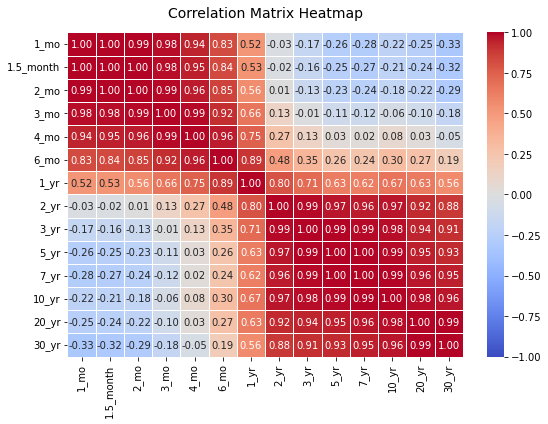

In [69]:
# lets create a heatmap so that we can check out any multicollinearity for the 14 tenors.
# create a heat map
# 1. plot figure by defining it first.

plt.figure(figsize = (8,6))

# 2. define the heatmap using sns 
sns.heatmap(
    corr_matrix_man_df,
    annot = True,              # displays the correlation numbers inside each square
    cmap = 'coolwarm',         # color gradient (blue for negative, red for positive)
    fmt = '.2f',               # formats the numerical values into 2 decimals.
    vmin = -1, vmax = 1,       # sets anchor bounds for color bar.
    linewidth = 0.5            # creates a thin line for scanability.
)

# 3. Add titles and show plot
plt.title('Correlation Matrix Heatmap', fontsize = 14, pad = 15)
plt.tight_layout()
plt.show()



# Just to confirm that these rates that are posted by the US treasury website are actually semi annual rates. 
# Meaning to bootstrap we will need to annualize the yields before we convert them to zero rates. 
# Please refer to the snapshot below for an excerpt of the answers asked in the FAQ section of the US Treasury website. 

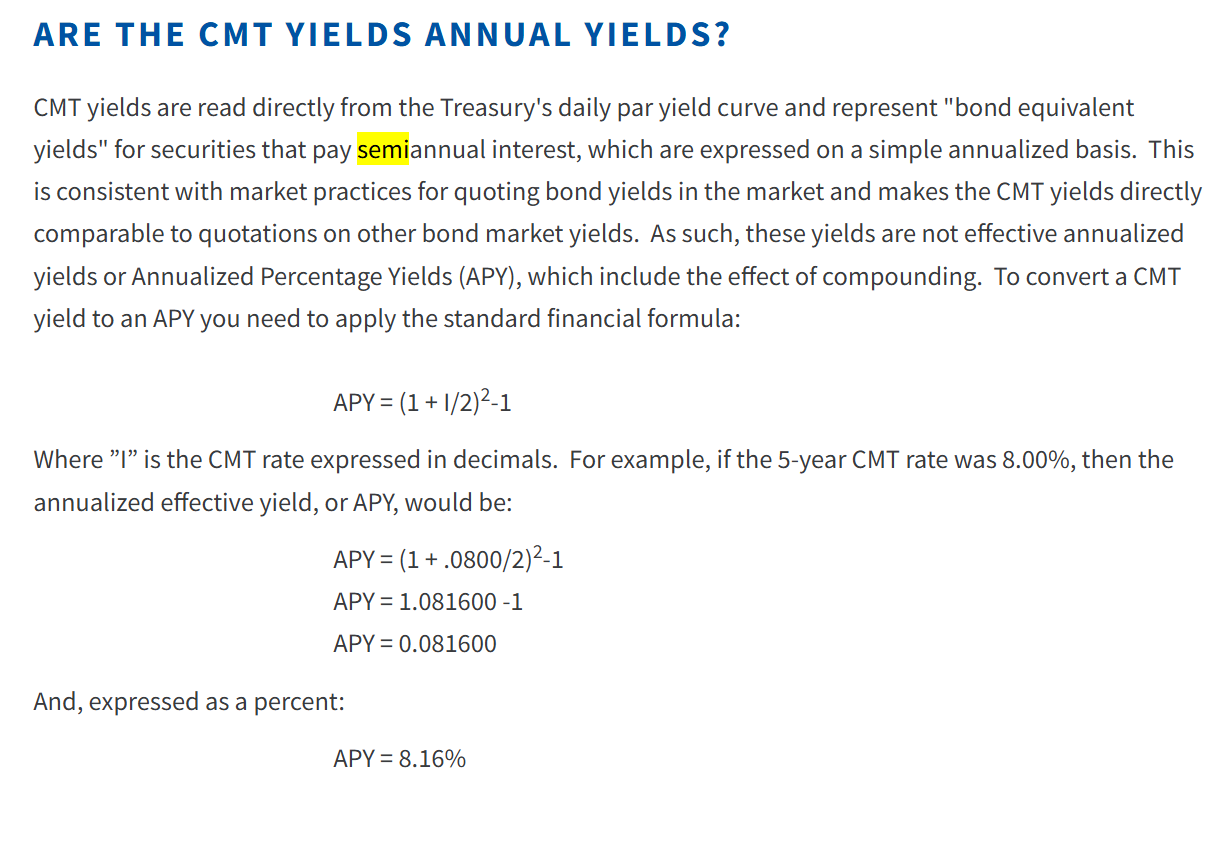

In [79]:
# we now need to do the bootstrapping first. 
display(bond_cf_df)

# we need to get the last dated par yields from the US treasury date.
latest_yields_df = treas_df3.iloc[-1,:].to_frame()
latest_yields_df = latest_yields_df.rename(columns = {0 : 'mkt_yields'})
#print(display(latest_yields_df))

#print(target_cols, tenor_list)

date_value = latest_yields_df.iloc[0,0]

#print(f"date_value is: {display(date_value)}")

# define the values for the dataframe
all_values = [date_value] + tenor_list
#print(f"all_values after including date_value is: {display(all_values)}")

bond_market_tenor_df = pd.DataFrame(all_values, index = latest_yields_df.index, columns = ['bond_market_tenor'])
#display(bond_market_tenor_df)

# left join these mofos.
total_bond_data_df = bond_market_tenor_df.merge(latest_yields_df, how = 'left', left_index = True, right_index = True)

# lets right join the total_bond_data_df with the bond_cf_df you just created. that way we have the complete tenors for each of these coupon cashflows.
bond_merge_df = total_bond_data_df.iloc[1:,:].merge(bond_cf_df[['tenor']], how = 'outer', left_on = ['bond_market_tenor'], right_on = ['tenor'])
display(bond_merge_df)

# merge the tenors together to combine them. 
bond_merge_df['comb_tenors'] = np.where(bond_merge_df['tenor'].isna(), bond_merge_df['bond_market_tenor'], bond_merge_df['tenor'])

# remove the other two tenors. 
bond_merge_df = bond_merge_df.drop(columns = ['tenor', 'bond_market_tenor'])

# arrange the columns 
bond_merge_df = bond_merge_df[['comb_tenors', 'mkt_yields']].sort_values(by = ['comb_tenors'], ascending  = True)

# divide the par yields into actual percentage form
bond_merge_df['mkt_yields'] = bond_merge_df['mkt_yields']/ 100

# interpolate the par yields before you start bootstrapping them 
bond_merge_df['mkt_yields'] = bond_merge_df['mkt_yields'].infer_objects(copy=False).interpolate(method = 'linear')

# now that we have the interpolated par yields, we need to start bootstrapping them. 
# as mentioned in the US Treasury statement in its FAQs section. the CMT yields are based on semiannual rates. meaning that we have to annualize the 
# yields which are increments of 0.5 years by the power of 2 to get the accurate rates to bootstrap. 
# link is here for reference. [link: https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics/interest-rates-frequently-asked-questions]
bond_merge_df['semi_ann_tenor_flag'] = bond_merge_df['comb_tenors'] % 0.5 
print(f"total_bond_data_df is: {display(total_bond_data_df)}")
display(bond_merge_df)

def bootstrapping_single_yield(market_yield, tenor):
    
    power_tenor = tenor * 2 
    freq = (1/tenor)
    market_yield = (((1 + market_yield/2)** (power_tenor))- 1) * freq # due to the market yields actually being quoted semiannually.
    
    return market_yield

bond_single_tenor_df = bond_merge_df.loc[bond_merge_df['semi_ann_tenor_flag'] > 0].copy()
    
bond_single_tenor_df['zero_rates'] = bond_single_tenor_df.apply(
    lambda row: bootstrapping_single_yield(row['mkt_yields'], row['comb_tenors']),
axis = 1)
display(bond_single_tenor_df)

# we now need to compute the bootstrapping for the semiannual par yields in a continuous manner. 
bond_semi_ann_tenor_df = bond_merge_df.loc[bond_merge_df['semi_ann_tenor_flag'] == 0].copy()
display(bond_semi_ann_tenor_df)


,no,tenor,coupon_amt,face_value,df,pv_cf,pv_cf2,dv01,pv_cf_conv
0,1,0.5,250000.0,0,0.975610,2.439024e+05,1.219512e+05,12.195122,1.829268e+05
1,2,1.0,250000.0,0,0.951814,2.379536e+05,2.379536e+05,23.795360,4.759072e+05
2,3,1.5,250000.0,0,0.928599,2.321499e+05,3.482248e+05,34.822478,8.705619e+05
3,4,2.0,250000.0,0,0.905951,2.264877e+05,4.529753e+05,45.297532,1.358926e+06
4,5,2.5,250000.0,0,0.883854,2.209636e+05,5.524089e+05,55.240893,1.933431e+06
5,6,3.0,250000.0,0,0.862297,2.155742e+05,6.467226e+05,64.672265,2.586891e+06
6,7,3.5,250000.0,0,0.841265,2.103163e+05,7.361071e+05,73.610708,3.312482e+06
7,8,4.0,250000.0,0,0.820747,2.051866e+05,8.207466e+05,82.074657,4.103733e+06
8,9,4.5,250000.0,0,0.800728,2.001821e+05,9.008194e+05,90.081941,4.954507e+06
9,10,5.0,250000.0,0,0.781198,1.952996e+05,9.764980e+05,97.649800,5.858988e+06


,bond_market_tenor,mkt_yields,tenor
0,0.083333,3.71,NaN
1,0.125,3.71,NaN
2,0.166667,3.71,NaN
3,0.25,3.78,NaN
4,0.333333,3.78,NaN
5,0.5,3.81,0.5
6,1.0,3.88,1.0
7,NaN,NaN,1.5
8,2.0,4.17,2.0
9,NaN,NaN,2.5


,bond_market_tenor,mkt_yields
date,2026-06-05 00:00:00,2026-06-05 00:00:00
1_mo,0.083333,3.71
1.5_month,0.125,3.71
2_mo,0.166667,3.71
3_mo,0.25,3.78
4_mo,0.333333,3.78
6_mo,0.5,3.81
1_yr,1.0,3.88
2_yr,2.0,4.17
3_yr,3.0,4.22


total_bond_data_df is: None


,comb_tenors,mkt_yields,semi_ann_tenor_flag
0,0.083333,0.037100,0.083333
1,0.125,0.037100,0.125
2,0.166667,0.037100,0.166667
3,0.25,0.037800,0.25
4,0.333333,0.037800,0.333333
5,0.5,0.038100,0.0
6,1.0,0.038800,0.0
7,1.5,0.040250,0.0
8,2.0,0.041700,0.0
9,2.5,0.041950,0.0


,comb_tenors,mkt_yields,semi_ann_tenor_flag,zero_rates
0,0.083333,0.0371,0.083333,0.036816
1,0.125,0.0371,0.125,0.036845
2,0.166667,0.0371,0.166667,0.036873
3,0.25,0.0378,0.25,0.037623
4,0.333333,0.0378,0.333333,0.037682


,comb_tenors,mkt_yields,semi_ann_tenor_flag
5,0.5,0.038100,0.0
6,1.0,0.038800,0.0
7,1.5,0.040250,0.0
8,2.0,0.041700,0.0
9,2.5,0.041950,0.0
10,3.0,0.042200,0.0
11,3.5,0.042375,0.0
12,4.0,0.042550,0.0
13,4.5,0.042725,0.0
14,5.0,0.042900,0.0


In [87]:
bond_semi_ann_tenor_df['semi_ann_yield'] = bond_semi_ann_tenor_df['mkt_yields']/ 2
display(bond_semi_ann_tenor_df)

zero_rates_list = []
disc_fact_list = []

for i in range(len(bond_semi_ann_tenor_df)):
    print(i)
    if i == 0:
        # lets find the discount factor since it has already factored in the tenor.
        discount_factor = (100/ (1 + bond_semi_ann_tenor_df.iloc[i,3]))
        target_zero_rate = bootstrapping_single_yield(bond_semi_ann_tenor_df.iloc[i,1], bond_semi_ann_tenor_df.iloc[i,0])
        print(discount_factor)
        print(target_zero_rate)
        zero_rates_list.append(target_zero_rate)
        disc_fact_list.append(discount_factor)
zero_rates_list

,comb_tenors,mkt_yields,semi_ann_tenor_flag,semi_ann_yield
5,0.5,0.038100,0.0,0.019050
6,1.0,0.038800,0.0,0.019400
7,1.5,0.040250,0.0,0.020125
8,2.0,0.041700,0.0,0.020850
9,2.5,0.041950,0.0,0.020975
10,3.0,0.042200,0.0,0.021100
11,3.5,0.042375,0.0,0.021187
12,4.0,0.042550,0.0,0.021275
13,4.5,0.042725,0.0,0.021362
14,5.0,0.042900,0.0,0.021450


0
98.13061184436485
0.03810000000000002
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


[0.03810000000000002]